# Phase 3: Model Training

In this phase, we train two machine learning classification models:

- Support Vector Machine (SVM)
- Decision Tree Classifier

Both models will be evaluated using standard classification metrics.

In [50]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

df = pd.read_csv("../data/processed/breast_cancer_processed.csv")

df.head()

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

svm_model = SVC(kernel="rbf", random_state=42)

svm_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [51]:
svm_predictions = svm_model.predict(X_test)

In [52]:
print("Accuracy :", accuracy_score(y_test, svm_predictions))
print("Precision:", precision_score(y_test, svm_predictions))
print("Recall   :", recall_score(y_test, svm_predictions))
print("F1 Score :", f1_score(y_test, svm_predictions))

Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112


In [53]:
conf_matrix = confusion_matrix(y_test, svm_predictions)

print(conf_matrix)

[[41  1]
 [ 1 71]]


In [54]:
print(classification_report(y_test, svm_predictions))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [55]:
joblib.dump(
    svm_model,
    "../models/svm_model.pkl"
)

['../models/svm_model.pkl']

## SVM Model Observations

- The SVM classifier achieved an accuracy of **98.25%**.
- Precision, Recall, and F1-score are all above **98%**, indicating excellent classification performance.
- The confusion matrix shows only **2 incorrect predictions**.
- The model demonstrates strong generalization and is well-suited for this binary classification problem.

In [56]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [57]:
dt_predictions = decision_tree.predict(X_test)

In [58]:
print("Accuracy :", accuracy_score(y_test, dt_predictions))
print("Precision:", precision_score(y_test, dt_predictions))
print("Recall   :", recall_score(y_test, dt_predictions))
print("F1 Score :", f1_score(y_test, dt_predictions))

Accuracy : 0.9210526315789473
Precision: 0.9565217391304348
Recall   : 0.9166666666666666
F1 Score : 0.9361702127659575


In [59]:
dt_conf_matrix = confusion_matrix(y_test, dt_predictions)

print(dt_conf_matrix)

[[39  3]
 [ 6 66]]


In [60]:
print(classification_report(y_test, dt_predictions))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        42
           1       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



In [61]:
joblib.dump(
    decision_tree,
    "../models/decision_tree_model.pkl"
)

['../models/decision_tree_model.pkl']

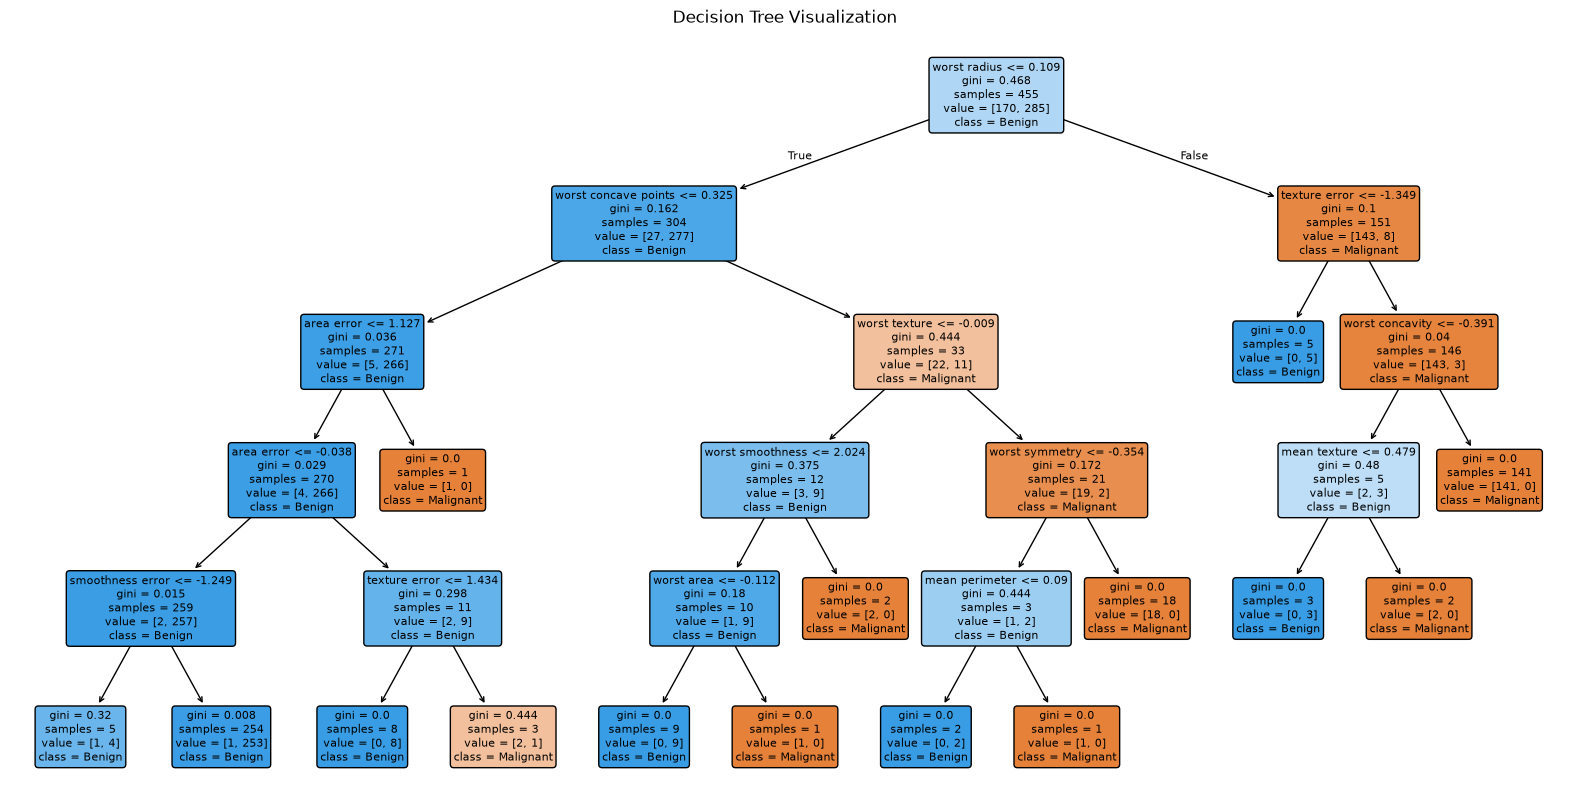

In [62]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    decision_tree,
    filled=True,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"],
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Visualization")

plt.show()

In [63]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "SVM": [
        accuracy_score(y_test, svm_predictions),
        precision_score(y_test, svm_predictions),
        recall_score(y_test, svm_predictions),
        f1_score(y_test, svm_predictions)
    ],
    "Decision Tree": [
        accuracy_score(y_test, dt_predictions),
        precision_score(y_test, dt_predictions),
        recall_score(y_test, dt_predictions),
        f1_score(y_test, dt_predictions)
    ]
})

comparison

,Metric,SVM,Decision Tree
0,Accuracy,0.982456,0.921053
1,Precision,0.986111,0.956522
2,Recall,0.986111,0.916667
3,F1 Score,0.986111,0.936170


In [64]:
comparison.to_csv(
    "../outputs/metrics/model_comparison.csv",
    index=False
)

In [65]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": decision_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
20,worst radius,0.714332
27,worst concave points,0.118831
11,texture error,0.053907
21,worst texture,0.031473
26,worst concavity,0.016712
24,worst smoothness,0.012978
13,area error,0.012371
1,mean texture,0.011536
28,worst symmetry,0.010987
23,worst area,0.008652


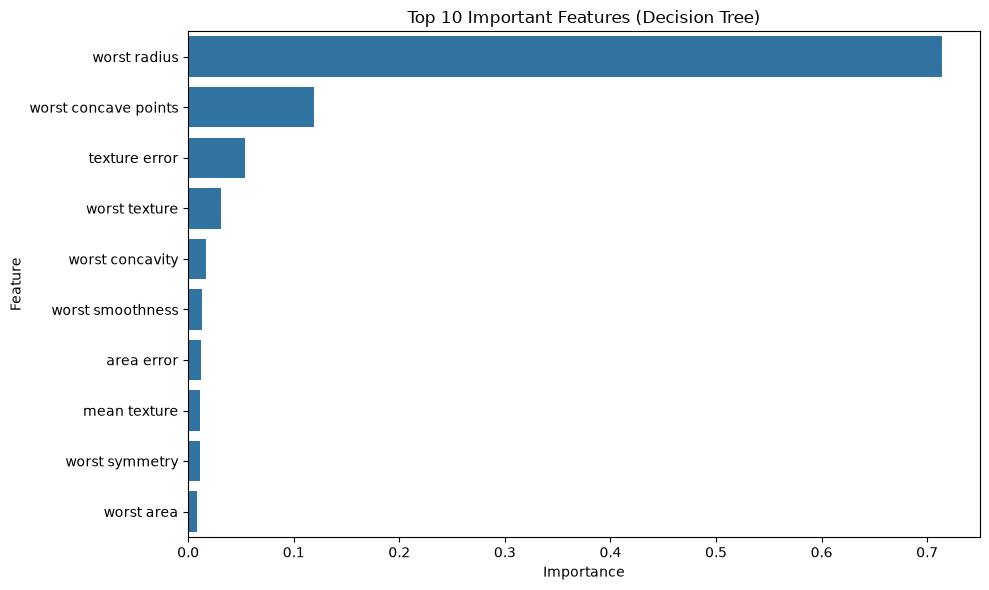

In [66]:
plt.figure(figsize=(10,6))
import seaborn as sns
sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features (Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig("../outputs/plots/feature_importance.png")
plt.show()